In [5]:
from sklearn.tree import DecisionTreeClassifier

features = [
    [1, 0],   # 1 hour studied, low attendance
    [2, 0],   # 2 hours studied, low attendance
    [2, 1],   # 2 hours studied, high attendance
    [4, 1],   # 4 hours studied, high attendance
    [5, 1],   # 5 hours studied, high attendance
    [6, 1],   # 6 hours studied, high attendance
]

labels = [
    "Fail",
    "Fail",
    "Pass",
    "Pass",
    "Pass",
    "Pass"
]

clf = DecisionTreeClassifier()

clf.fit(features, labels)

print(clf.predict([[1, 0]]))
print(clf.predict([[5, 1]]))
print(clf.predict([[3, 1]]))
print(clf.predict([[1, 1]]))


['Fail']
['Pass']
['Pass']
['Pass']


    age  income  student  buy_laptop
0    22      25        1           1
1    25      30        1           1
2    28      35        1           1
3    35      60        0           1
4    42      80        0           0
5    45      75        0           0
6    52      90        0           0
7    23      28        1           1
8    30      45        1           1
9    38      65        0           1
10   48      85        0           0
11   55      95        0           0
Predictions: [0 1 1]
Actual: [0 1 1]

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



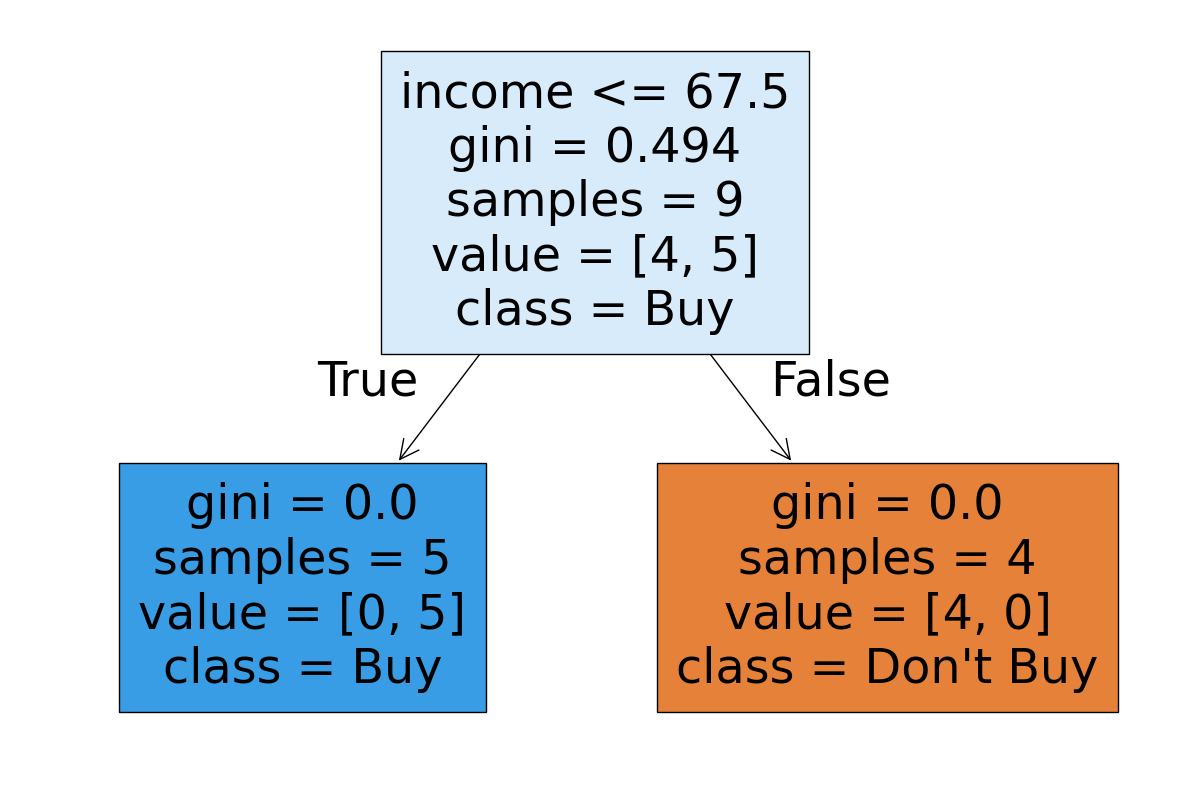

In [7]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt


# -----------------------------
# 1. Create the dataset
# -----------------------------

data = {
    "age": [22, 25, 28, 35, 42, 45, 52, 23, 30, 38, 48, 55],
    "income": [25, 30, 35, 60, 80, 75, 90, 28, 45, 65, 85, 95],
    "student": [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],

    # 1 = Buy laptop, 0 = Don't buy
    "buy_laptop": [1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0]
}

df = pd.DataFrame(data)

print(df)


# -----------------------------
# 2. Separate features and target
# -----------------------------

X = df[["age", "income", "student"]]
y = df["buy_laptop"]


# -----------------------------
# 3. Split data
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


# -----------------------------
# 4. Create Decision Tree
# -----------------------------

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)


# -----------------------------
# 5. Train the model
# -----------------------------

model.fit(X_train, y_train)


# -----------------------------
# 6. Make predictions
# -----------------------------

y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual:", y_test.values)


# -----------------------------
# 7. Evaluate the model
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# -----------------------------
# 8. Visualize the tree
# -----------------------------

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Don't Buy", "Buy"],
    filled=True
)

plt.tight_layout()

plt.show()

In [12]:
print(len(X))
print(len(y))
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

12
12
9
3
9
3
